In [ ]:
!pip install jax "jax[cuda13]" transformers huggingface_hub

# SAM — Segment Anything Model

**Paper:** [arXiv:2304.02643](https://arxiv.org/abs/2304.02643) — *Segment Anything* (Kirillov et al., Meta AI, 2023).  
**HF source:** [facebook/sam-vit-base](https://huggingface.co/facebook/sam-vit-base)

This notebook walks through a **from-scratch JAX implementation** of SAM (ViT-Base variant).

---

### Paper Overview

SAM's central contribution: a **promptable segmentation foundation model** that generalises to any image and any object class — no fine-tuning needed.

| Component | Role |
|---|---|
| **Image Encoder** | ViT-B/16 pretrained via MAE; 1024×1024 → 64×64×256 feature map |
| **Prompt Encoder** | Embeds points, boxes, and masks into a shared 256-d token space |
| **Mask Decoder** | 2-layer Two-Way Transformer; outputs 3 candidate masks + IoU scores |

### Architecture at a glance

```
Input: 1024×1024×3
  ↓  Image Encoder (ViT-B, 12 layers — windowed + global attention)
     → (64, 64, 768)  →  Neck (1×1 convs)  →  (64, 64, 256)

Prompt: points / boxes / masks
  ↓  Prompt Encoder → sparse tokens (N×256) + dense map (64×64×256)

  ↓  Mask Decoder (2× Two-Way Transformer block)
     → 3 masks @ 256×256  +  3 IoU scores
```

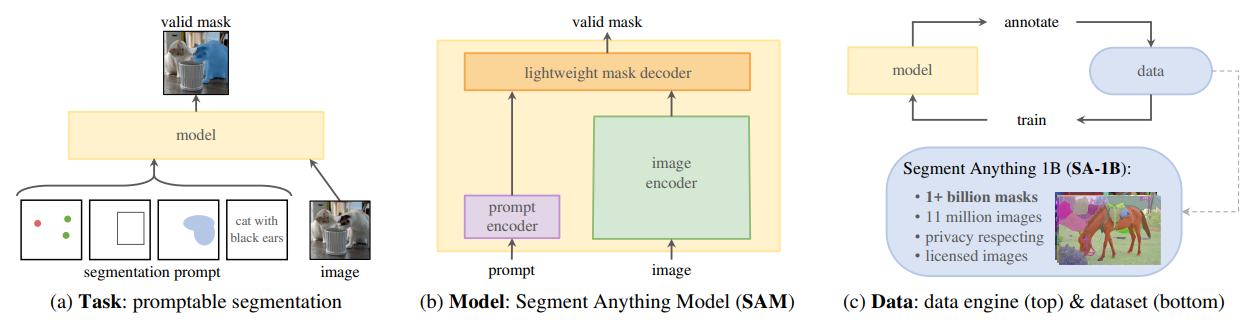

### Imports

In [ ]:
import json
from dataclasses import dataclass
from typing import Optional

import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
from jax import tree_util
import PIL.Image as Image
from safetensors.numpy import load_file
from transformers import AutoTokenizer
from einops import rearrange, repeat

### Load Weights

SAM weights are loaded from the HuggingFace `facebook/sam-vit-base` checkpoint in SafeTensors format. The checkpoint contains three top-level modules: `vision_encoder`, `prompt_encoder`, and `mask_decoder`, plus the shared `positional_embedding` used by both the prompt encoder and mask decoder.

**Setup:** Download the model weights and config from HuggingFace and place them at `models/resnet/` relative to your workspace root

In [ ]:
HF_REPO_ID = "facebook/sam-vit-base"
LOCAL_DIR_PATH = "workspace/models/sam"

In this section, we download the weights of the model of interest from huggingface to use in our implementation.

In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)
print(f"Downloaded repository path: {local_dir}")

In [ ]:
WEIGHTS_PATH = f"{LOCAL_DIR_PATH}/model.safetensors"
CONFIG_PATH = f"{LOCAL_DIR_PATH}/config.json"
IMAGE_PATH = f"{LOCAL_DIR_PATH}/cat.png"

checkpoint_path = WEIGHTS_PATH
hf_weights = load_file(checkpoint_path)

### Weight Conversion Utilities

PyTorch and JAX use different axis conventions, so we transpose weights on load:

| Layer type | PyTorch shape | JAX shape |
|---|---|---|
| Conv2d | `(C_out, C_in, kH, kW)` | `(kH, kW, C_in, C_out)` |
| Linear | `(C_out, C_in)` | `(C_in, C_out)` |
| Embeddings / biases | unchanged | unchanged |

`_unflatten_dict` reconstructs the nested weight dict from the flat `"module.sub.weight"` key format used by SafeTensors.

In [ ]:
def _unflatten_dict(
    flat_dict: dict,
    delimiter: str = '.'
):
    nested_dict = {}
    for key, value in flat_dict.items():
        parts = key.split(delimiter)
        d = nested_dict
        for part in parts[:-1]:
            if part not in d:
                d[part] = {}
            d = d[part]
        d[parts[-1]] = value
    return nested_dict

def universal_pt_to_jax(
    state_dict: dict,
    dtype = jnp.float32
):
    jax_weights_flat = {}

    for key, val in state_dict.items():
        w = jnp.array(val.detach().cpu(), dtype=dtype)
        shape = w.shape
        rank = len(shape)

        if rank == 4 and "weight" in key:
            w = jnp.transpose(w, (2, 3, 1, 0))
        elif rank == 2 and "weight" in key and "embeddings" not in key:
            w = w.T
        else:
            pass

        jax_weights_flat[key] = w

    return _unflatten_dict(jax_weights_flat)

def list_layer_shapes(
    jax_params: dict
):
    flat_params = tree_util.tree_leaves_with_path(jax_params)

    print(f"{'Layer Path':<70} | {'Shape':<20}")
    print("-" * 95)

    for path, val in flat_params:
        path_str = ".".join([str(p.key if hasattr(p, 'key') else p) for p in path])
        print(f"{path_str:<70} | {str(val.shape):<20}")

def print_param_tree(
    params: dict,
    indent_prefix: str = "",
    is_last: bool = True
):
    items = list(params.items())
    for i, (key, value) in enumerate(items):
        is_last_item = (i == len(items) - 1)
        marker = "└── " if is_last_item else "├── "
        line_prefix = indent_prefix + marker
        next_prefix = indent_prefix + ("    " if is_last_item else "│   ")

        if isinstance(value, dict):
            print(f"{line_prefix}{key}")
            print_param_tree(value, next_prefix, is_last_item)
        else:
            label = f"{line_prefix}{key}:"
            shape_str = str(value.shape)
            print(f"{label:<60} {shape_str}")


In [51]:
jax_weights = universal_pt_to_jax(hf_weights)

In [52]:
for key in jax_weights.keys():
    print(f"Top-level module: {key}")

Top-level module: mask_decoder
Top-level module: prompt_encoder
Top-level module: shared_image_embedding
Top-level module: vision_encoder


In [53]:
print_param_tree(jax_weights['prompt_encoder'])

├── mask_embed
│   ├── conv1
│   │   ├── bias:                                            (4,)
│   │   └── weight:                                          (2, 2, 1, 4)
│   ├── conv2
│   │   ├── bias:                                            (16,)
│   │   └── weight:                                          (2, 2, 4, 16)
│   ├── conv3
│   │   ├── bias:                                            (256,)
│   │   └── weight:                                          (1, 1, 16, 256)
│   ├── layer_norm1
│   │   ├── bias:                                            (4,)
│   │   └── weight:                                          (4,)
│   └── layer_norm2
│       ├── bias:                                            (16,)
│       └── weight:                                          (16,)
├── no_mask_embed
│   └── weight:                                              (256, 1)
├── not_a_point_embed
│   └── weight:                                              (256, 1)
└── point_embed
    ├── 0
    

In [54]:
print_param_tree(jax_weights['shared_image_embedding'])

└── positional_embedding:                                    (2, 128)


In [55]:
print_param_tree(jax_weights['vision_encoder'])

├── layers
│   ├── 0
│   │   ├── attn
│   │   │   ├── proj
│   │   │   │   ├── bias:                                    (768,)
│   │   │   │   └── weight:                                  (768, 768)
│   │   │   ├── qkv
│   │   │   │   ├── bias:                                    (2304,)
│   │   │   │   └── weight:                                  (768, 2304)
│   │   │   ├── rel_pos_h:                                   (27, 64)
│   │   │   └── rel_pos_w:                                   (27, 64)
│   │   ├── layer_norm1
│   │   │   ├── bias:                                        (768,)
│   │   │   └── weight:                                      (768,)
│   │   ├── layer_norm2
│   │   │   ├── bias:                                        (768,)
│   │   │   └── weight:                                      (768,)
│   │   └── mlp
│   │       ├── lin1
│   │       │   ├── bias:                                    (3072,)
│   │       │   └── weight:                                  (768, 3072)


In [56]:
print_param_tree(jax_weights['mask_decoder'])

├── iou_prediction_head
│   ├── layers
│   │   └── 0
│   │       ├── bias:                                        (256,)
│   │       └── weight:                                      (256, 256)
│   ├── proj_in
│   │   ├── bias:                                            (256,)
│   │   └── weight:                                          (256, 256)
│   └── proj_out
│       ├── bias:                                            (4,)
│       └── weight:                                          (256, 4)
├── iou_token
│   └── weight:                                              (256, 1)
├── mask_tokens
│   └── weight:                                              (256, 4)
├── output_hypernetworks_mlps
│   ├── 0
│   │   ├── layers
│   │   │   └── 0
│   │   │       ├── bias:                                    (256,)
│   │   │       └── weight:                                  (256, 256)
│   │   ├── proj_in
│   │   │   ├── bias:                                        (256,)
│   │   │   └── weight:

### Preprocessing

SAM requires a precise preprocessing pipeline — it is **not** a simple resize-and-normalise:

1. **Aspect-ratio-preserving resize** — the longest edge is scaled to 1024; the short edge is scaled proportionally.
2. **Zero-pad** to 1024 × 1024 (bottom-right padding only) — the padding region is masked out; the encoder never "sees" it as real content.
3. **Normalise** with ImageNet mean/std (`[0.485, 0.456, 0.406]` / `[0.229, 0.224, 0.225]`).

In [57]:
def sam_processor(
    image_path: str,
    target_size: int = 1024
):
    image = Image.open(image_path).convert("RGB")

    old_w, old_h = image.size
    scale = target_size / max(old_w, old_h)
    new_w, new_h = int(old_w * scale + 0.5), int(old_h * scale + 0.5)
    img_resized = image.resize((new_w, new_h), resample=Image.BILINEAR)

    x = jnp.array(np.array(img_resized), dtype=jnp.float32) / 255.0

    mean = jnp.array([0.485, 0.456, 0.406])
    std = jnp.array([0.229, 0.224, 0.225])
    x = (x - mean) / std

    pad_h = target_size - new_h
    pad_w = target_size - new_w

    x = jnp.pad(x, ((0, pad_h), (0, pad_w), (0, 0)), mode='constant', constant_values=0.0)
    x = rearrange(x, 'h w c -> 1 h w c')

    return x.astype(jnp.float32)


## Vision Encoder (ViT-B with MAE Pretraining)

SAM uses a **Vision Transformer (ViT-Base)** pretrained with **Masked Autoencoding (MAE)** — the encoder learned to reconstruct randomly masked patches, giving it rich spatial representations without manual labels.

Key facts for the ViT-Base SAM variant:

| Property | Value |
|---|---|
| Input resolution | 1024 × 1024 |
| Patch size | 16 × 16 → **64 × 64 = 4096 tokens** |
| Embed dim | 768 |
| Layers / heads | 12 / 12 |
| Windowed attention | window = 14×14 on most layers (reduces O(n²) cost) |
| Global attention | layers `[2, 5, 8, 11]` — see full 4096-token sequence |
| Neck output | 768 → 256 channels (two 1×1 convs) |

In [58]:
GLOBAL_ATTN_LAYERS = [2, 5, 8, 11]

### Patch Embeddings

A single **16×16 strided convolution** (`stride=16`) converts the 1024×1024 image into a 64×64 grid of 768-d patch tokens — identical to the ViT patch projection. Learned **absolute positional embeddings** are then added to the token grid before the transformer layers.

In [59]:
def sam_patch_embeddings(
    pixel_values: jax.Array, # (1, 1024, 1024, 3)
    patch_params: dict
):
    w = patch_params['projection']['weight']
    b = patch_params['projection']['bias']

    embeddings = jax.lax.conv_general_dilated(
        lhs=pixel_values,
        rhs=w,
        window_strides=(16, 16),
        padding='VALID',
        dimension_numbers=('NHWC', 'HWIO', 'NHWC')
    )

    embeddings = embeddings + b
    return embeddings


### Window Partitioning

Global attention over 4096 tokens costs $O(n^2) = O(4096^2) \approx 16M$ operations per layer — prohibitively expensive. SAM's solution: run **local windowed attention** on 14×14 patches of tokens for most layers, and only perform full global attention on 4 designated "checkpoint" layers.

`window_partition` rearranges the `(B, 64, 64, C)` token grid into `(B × num_windows, 14, 14, C)` — each window attends independently. `window_unpartition` reverses this after attention, restoring the full spatial layout. A pad step handles grid sizes that aren't divisible by 14.

In [60]:
def window_partition(
    x: jax.Array,     # (B, H, W, C)
    window_size: int
):
    B, H, W, C = x.shape

    pad_h = (window_size - H % window_size) % window_size
    pad_w = (window_size - W % window_size) % window_size
    if pad_h > 0 or pad_w > 0:
        x = jnp.pad(x, ((0, 0), (0, pad_h), (0, pad_w), (0, 0)))

    Hp, Wp = H + pad_h, W + pad_w

    x = rearrange(x, 'b (num_h win_h) (num_w win_w) c -> (b num_h num_w) win_h win_w c', win_h=window_size, win_w=window_size)

    return x, (Hp, Wp)

def window_unpartition(
    x: jax.Array,          # (B*num_h*num_w, win_h, win_w, C)
    window_size: int,
    pad_hw: tuple,
    original_hw: tuple
):
    Hp, Wp = pad_hw
    H, W = original_hw
    num_h = Hp // window_size
    num_w = Wp // window_size
    B = x.shape[0] // (num_h * num_w)

    x = rearrange(x, '(b num_h num_w) win_h win_w c -> b (num_h win_h) (num_w win_w) c',
                  b=B, num_h=num_h, num_w=num_w)

    return x[:, :H, :W, :]


### Relative Positional Encoding

SAM augments each attention layer with **axially-decomposed relative position bias** (from ViTDet). Rather than a full 2D relative bias table (which would be `n² × n²`), the bias is factored into separate **row** and **column** 1D tables, then combined:

$$\text{Attn}_{ij} = \text{Attn}_{ij} + B^h_{r_i, r_j} + B^w_{c_i, c_j}$$

where $B^h$ and $B^w$ are the learned row and column bias tables respectively. This halves the parameter count and keeps the bias computation efficient even at different scales.

`get_rel_pos` handles the case where query and key windows are different sizes (e.g. during global attention) by linearly interpolating the learned bias table to the required length.

In [61]:
def get_rel_pos(
    size_q: int,
    size_k: int,
    rel_pos: jax.Array  # (2*max_size-1, head_dim)
):
    max_rel_dist = 2 * max(size_q, size_k) - 1

    if rel_pos.shape[0] != max_rel_dist:
        rel_pos_resized = jax.image.resize(
            rel_pos,
            shape=(max_rel_dist, rel_pos.shape[1]),
            method='linear'
        )
    else:
        rel_pos_resized = rel_pos

    q_coords = jnp.arange(size_q)[:, None] * max(size_k / size_q, 1.0)
    k_coords = jnp.arange(size_k)[None, :] * max(size_q / size_k, 1.0)
    relative_coords = (q_coords - k_coords) + (size_k - 1) * max(size_q / size_k, 1.0)

    return rel_pos_resized[relative_coords.astype(jnp.int32)]


def apply_sam_rel_pos(
    attn: jax.Array,    # (B, num_heads, H*W, H*W)
    q: jax.Array,       # (B, num_heads, H*W, head_dim)
    params: dict,
    size_q: int,
    size_k: int = None
):
    if size_k is None:
        size_k = size_q

    rel_pos_h = get_rel_pos(size_q, size_k, params['rel_pos_h'])
    rel_pos_w = get_rel_pos(size_q, size_k, params['rel_pos_w'])

    q_2d = rearrange(q, 'b nh (h w) hd -> b nh h w hd', h=size_q, w=size_q)

    rel_h = jnp.einsum('bnhwd,hkd->bnhwk', q_2d, rel_pos_h)
    rel_w = jnp.einsum('bnhwd,wkd->bnhwk', q_2d, rel_pos_w)

    decomposed = rel_h[..., None] + rel_w[..., None, :]
    attn = attn + rearrange(decomposed, 'b nh h w kh kw -> b nh (h w) (kh kw)')

    return attn


### Vision Attention & MLP

Standard ViT multi-head self-attention, adapted for SAM's 2D token grid:

- **Fused QKV projection** — a single linear layer produces Q, K, V together (more efficient than three separate projections)
- Relative position bias is added to the raw attention logits *before* softmax
- The MLP uses **GELU** activation with a 4× hidden-dim expansion (768 → 3072 → 768)

During windowed layers, attention operates on `(B×num_windows, 14, 14, C)` inputs. During global layers, it operates on the full `(B, 64, 64, C)` grid.

In [62]:
def sam_layer_norm(
    x: jax.Array, # (..., C)
    params: dict,
    eps: float = 1e-6
):
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)
    x = (x - mean) / jnp.sqrt(var + eps)
    return x * params['weight'] + params['bias']

def sam_vision_attention(
    x: jax.Array,       # (B, H, W, C)
    params: dict,
    num_heads: int = 12,
    window_size: int = 0
):
    B, H, W, C = x.shape
    head_dim = C // num_heads

    rel_pos_size = window_size if window_size > 0 else H

    x_flat = rearrange(x, 'b h w c -> b (h w) c')
    qkv = x_flat @ params['qkv']['weight'] + params['qkv']['bias']

    qkv = rearrange(qkv, 'b (h w) (three nh hd) -> three b nh (h w) hd',
                h=H, w=W, three=3, nh=num_heads, hd=head_dim)

    q, k, v = qkv[0], qkv[1], qkv[2]

    attn = jnp.einsum('bhid,bhjd->bhij', q, k) / jnp.sqrt(head_dim)

    attn = apply_sam_rel_pos(attn, q, params, rel_pos_size)

    attn = jax.nn.softmax(attn, axis=-1)

    out = jnp.einsum('bhlm,bhmd->bhld', attn, v)
    out = rearrange(out, 'b nh (h w) hd -> b h w (nh hd)', h=H, w=W)

    out = out @ params['proj']['weight'] + params['proj']['bias']

    return out

def sam_mlp(
    x: jax.Array, # (B, H, W, C) or (B, N, C)
    params: dict
):
    fc1 = params['lin1']
    fc2 = params['lin2']

    x = x @ fc1['weight'] + fc1['bias']
    x = jnn.gelu(x)
    x = x @ fc2['weight'] + fc2['bias']

    return x


### Encoder Layer & Neck

Each **encoder layer** follows the standard pre-norm ViT recipe:
```
x = x + Attention(LayerNorm(x))   ← with window partition/unpartition for windowed layers
x = x + MLP(LayerNorm(x))
```

The **Neck** is a lightweight output projection applied after all 12 transformer layers. It consists of two 1×1 convolutions separated by Layer Norm, compressing the channel dimension **768 → 256**. This brings the image features to the same dimensionality as the prompt embeddings used in the decoder.

In [63]:
def sam_vision_layer_forward(
    x: jax.Array,       # (B, H, W, C)
    layer_params: dict,
    window_size: int = 0
):
    residual = x
    x = sam_layer_norm(x, layer_params['layer_norm1'])

    if window_size > 0:
        original_hw = x.shape[1], x.shape[2]
        x, pad_hw = window_partition(x, window_size)

    x = sam_vision_attention(x, layer_params['attn'])

    if window_size > 0:
        x = window_unpartition(x, window_size, pad_hw, original_hw)

    x = residual + x

    residual = x
    x = sam_layer_norm(x, layer_params['layer_norm2'])

    x = sam_mlp(x, layer_params['mlp'])
    x = residual + x

    return x

def sam_neck_forward(
    x: jax.Array, # (B, H, W, C)
    neck_params: dict
):
    x = jax.lax.conv_general_dilated(
        lhs=x,
        rhs=neck_params['conv1']['weight'],
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NHWC', 'HWIO', 'NHWC')
    )

    x = sam_layer_norm(x, neck_params['layer_norm1'])

    x = jax.lax.conv_general_dilated(
        lhs=x,
        rhs=neck_params['conv2']['weight'],
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NHWC', 'HWIO', 'NHWC')
    )

    x = sam_layer_norm(x, neck_params['layer_norm2'])

    return x


In [64]:
def sam_vision_encoder_forward(
    pixel_values: jax.Array, # (1, 1024, 1024, 3)
    params: dict
):
    hidden_states = sam_patch_embeddings(pixel_values, params['patch_embed'])

    if 'pos_embed' in params:
        hidden_states = hidden_states + params['pos_embed']

    print("After patch embedding, hidden_states.shape:", hidden_states.shape)

    for i in range(len(params['layers'])):
        layer_params = params['layers'][str(i)]
        window_size = 0 if i in GLOBAL_ATTN_LAYERS else 14
        hidden_states = sam_vision_layer_forward(hidden_states, layer_params, window_size)

    print("After vision layers, hidden_states.shape:", hidden_states.shape)

    hidden_states = sam_neck_forward(hidden_states, params['neck'])
    print("After neck, hidden_states.shape:", hidden_states.shape)

    return hidden_states


In [65]:
image = sam_processor(IMAGE_PATH)
image_encoding = sam_vision_encoder_forward(image, jax_weights['vision_encoder'])

After patch embedding, hidden_states.shape: (1, 64, 64, 768)
After vision layers, hidden_states.shape: (1, 64, 64, 768)
After neck, hidden_states.shape: (1, 64, 64, 256)


## Prompt Encoder

The Prompt Encoder converts user prompts into a common **256-d embedding space** shared with the image features.

| Prompt type | Encoding strategy | Output shape |
|---|---|---|
| **Points** | Fourier pos. enc. + learnable label token (fg / bg / pad) | sparse `(N, 256)` |
| **Boxes** | Fourier pos. enc. of Top Left corner + Bottom Right corner, each with a label token | sparse `(2, 256)` |
| **Masks** | Small CNN (3× conv, stride-2 downsampling) | dense `(64, 64, 256)` |

If no mask prompt is given, a **learned "no-mask" embedding** is broadcast to fill the dense slot.

### Fourier Positional Encoding

SAM encodes spatial coordinates using a **Fourier feature projection** — the standard sinusoidal approach used in NeRF and many modern vision models.

Given normalised coordinates in $[-1, 1]$, a learned matrix $W \in \mathbb{R}^{2 \times 128}$ projects them into 128 frequencies, then sin and cos are applied and concatenated:

$$\text{PE}(x, y) = [\sin(2\pi W [x, y]^\top),\ \cos(2\pi W [x, y]^\top)] \in \mathbb{R}^{256}$$

This gives a continuous, high-frequency representation of position that generalises better than discrete learned embeddings. The same positional encoding function is shared between the prompt encoder and the mask decoder.

In [66]:
def get_sam_pos_embedding(
    input_coords: jax.Array, # (..., 2)
    pos_weight: jax.Array    # (2, 128)
):
    coords = 2 * input_coords - 1
    projection = coords @ pos_weight
    projection = 2 * jnp.pi * projection

    return jnp.concatenate([jnp.sin(projection), jnp.cos(projection)], axis=-1)


### Point & Box Embeddings

**Points:** Each point gets a Fourier-encoded position embedding, then a **learnable label token** is added on top:
- Label `1` (foreground) → add `point_embed[1]`
- Label `0` (background) → add `point_embed[0]`
- Label `-1` (padding) → replace entirely with `not_a_point_embed`

**Boxes:** A box is encoded as its **top-left and bottom-right corners** — two separate Fourier-encoded positions, with corner-specific label tokens (`point_embed[2]` and `point_embed[3]`). This gives the decoder explicit corner semantics.

Both result in sparse `(N, 256)` token sequences that are concatenated and passed to the decoder.

In [67]:
def sam_embed_points(
    params: dict,
    shared_image_embedding_params: dict,
    points: jax.Array,  # (B, N, 1, 2)
    labels: jax.Array,  # (B, 1, N)
    input_res: int = 1024,
    pad: bool = False
):
    if pad:
        pad_point = jnp.zeros((*points.shape[:-2], 1, 2))
        pad_label = -jnp.ones((*labels.shape[:-1], 1))
        points = jnp.concatenate([points, pad_point], axis=-2)
        labels = jnp.concatenate([labels, pad_label], axis=-1)

    coords = (points + 0.5) / input_res

    pos_embeds = get_sam_pos_embedding(coords, shared_image_embedding_params['positional_embedding'])

    p0 = params['point_embed']['0']['weight'].squeeze()
    p1 = params['point_embed']['1']['weight'].squeeze()
    not_a_point = params['not_a_point_embed']['weight'].squeeze()

    final_embeddings = pos_embeds

    final_embeddings += jnp.where((labels == 0)[..., None], p0, 0.0)
    final_embeddings += jnp.where((labels == 1)[..., None], p1, 0.0)

    final_embeddings = jnp.where((labels == -1)[..., None], not_a_point, final_embeddings)

    return final_embeddings

def sam_embed_boxes(
    params: dict,
    shared_image_embedding_params: dict,
    boxes: jax.Array,   # (B, N, 4)
    input_res: int = 1024
):
    B, N, _ = boxes.shape

    coords = boxes.reshape(B, N, 2, 2)
    coords = (coords + 0.5) / input_res

    corner_embeddings = get_sam_pos_embedding(coords, shared_image_embedding_params['positional_embedding'])

    p2 = params['point_embed']['2']['weight'].squeeze()
    p3 = params['point_embed']['3']['weight'].squeeze()

    tl_corner = corner_embeddings[:, :, 0, :] + p2
    br_corner = corner_embeddings[:, :, 1, :] + p3

    return jnp.stack([tl_corner, br_corner], axis=2)


### Mask Embeddings (Dense Prompt Path)

When a mask prompt is provided (e.g. a rough segmentation from a previous step), it is encoded by a small **3-layer CNN**:

```
Mask (1, H, W)  →  Conv2d (stride 2)  →  LN  →  GELU
                →  Conv2d (stride 2)  →  LN  →  GELU
                →  Conv2d (stride 1)  →  (64, 64, 256)
```

Two stride-2 convolutions halve the spatial resolution twice, matching the 64×64 image feature grid. The output is added **element-wise** to the image features before the decoder — providing spatially-grounded mask context.

If no mask is given, a **learned scalar embedding** (`no_mask_embed`) is broadcast across the full 64×64 grid as the dense placeholder.

In [68]:
def sam_layer_norm(
    x: jax.Array, # (..., C)
    params: dict,
    eps: float = 1e-6
):
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)
    x = (x - mean) / jnp.sqrt(var + eps)
    return x * params['weight'] + params['bias']

def sam_embed_masks(
    masks: jax.Array, # (B, 1, H, W)
    params: dict
):
    masks = rearrange(masks, 'b c h w -> b h w c')

    hidden_states = jax.lax.conv_general_dilated(
        lhs=masks,
        rhs=params['conv1']['weight'],
        window_strides=(2, 2),
        padding='SAME',
        dimension_numbers=('NHWC', 'HWIO', 'NHWC')
    )
    hidden_states = sam_layer_norm(hidden_states, params['layer_norm1'])
    hidden_states = jnn.gelu(hidden_states)

    hidden_states = jax.lax.conv_general_dilated(
        lhs=hidden_states,
        rhs=params['conv2']['weight'],
        window_strides=(2, 2),
        padding='SAME',
        dimension_numbers=('NHWC', 'HWIO', 'NHWC')
    )
    hidden_states = sam_layer_norm(hidden_states, params['layer_norm2'])
    hidden_states = jnn.gelu(hidden_states)

    dense_embeddings = jax.lax.conv_general_dilated(
        lhs=hidden_states,
        rhs=params['conv3']['weight'],
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NHWC', 'HWIO', 'NHWC')
    )

    return dense_embeddings


In [69]:
def prompt_encoder_forward(
    params: dict,
    shared_image_embedding_params: dict,
    input_points: jax.Array = None,  # (B, 1, N, 2)
    input_labels: jax.Array = None,  # (B, 1, N)
    input_boxes: jax.Array = None,   # (B, N, 4)
    input_masks: jax.Array = None,   # (B, 1, H, W)
    image_embedding_size: tuple = (64, 64)
):
    sparse_embeddings = []
    batch_size = 1

    if input_points is not None:
        batch_size = input_points.shape[0]
        p_embeds = sam_embed_points(
            params,
            shared_image_embedding_params,
            input_points,
            input_labels,
            pad=(input_boxes is None)
        )
        sparse_embeddings.append(p_embeds)

    if input_boxes is not None:
        batch_size = input_boxes.shape[0]
        b_embeds = sam_embed_boxes(params, shared_image_embedding_params, input_boxes)
        b_embeds = b_embeds.reshape(batch_size, -1, 256)
        sparse_embeddings.append(b_embeds)

    if len(sparse_embeddings) > 0:
        final_sparse = jnp.concatenate(sparse_embeddings, axis=1)
    else:
        final_sparse = params['not_a_point_embed']['weight'].reshape(1, 1, 256)

    if input_masks is not None:
        final_dense = sam_embed_masks(input_masks, params['mask_embed'])
    else:
        no_mask_weight = rearrange(params['no_mask_embed']['weight'], 'c 1 -> 1 c 1 1')
        final_dense = repeat(no_mask_weight, '1 c 1 1 -> b h w c', b=batch_size, h=image_embedding_size[0], w=image_embedding_size[1])

    return final_sparse, final_dense


In [70]:
# Example usage of prompt_encoder_forward with dummy inputs. The given coordinate points to the center of the image.
input_points = jnp.array([[[[512.0, 512.0]]]])

# Label 1 indicates a positive point, label 0 would indicate a negative point, and label -1 would indicate no point (used for padding when boxes are not provided).
input_labels = jnp.array([[[1]]])

sparse_embeddings, dense_embeddings = prompt_encoder_forward(
    jax_weights['prompt_encoder'],
    jax_weights['shared_image_embedding'],
    input_points=input_points,
    input_labels=input_labels,
)


In [71]:
sparse_embeddings.shape, dense_embeddings.shape

((1, 1, 2, 256), (1, 64, 64, 256))

## Mask Decoder

The Mask Decoder refines image features and prompt tokens into segmentation masks. Its core is a **Two-Way Transformer** — unlike standard cross-attention, both token and image streams attend to each other bidirectionally.

Each decoder block runs 4 steps:
1. **Token self-attention** — prompt tokens refine among themselves
2. **Token → Image cross-attention** — tokens query the image features
3. **Token MLP** — per-token feedforward
4. **Image → Token cross-attention** — image features update from tokens

After 2 such blocks, the image features are **4× upscaled** via transposed convolutions. A **hypernetwork** then generates each mask: each of the 4 mask tokens is passed through a small MLP → dot-producted with the upscaled image to produce a per-pixel mask.

SAM always predicts **4 masks** (1 "whole object" + 3 granularity variants) plus an IoU score for each. `multimask_output=True` returns the 3 most granular candidates.

### Image Positional Embeddings

The decoder needs positional information for the 64×64 image feature grid. Rather than learned embeddings, SAM uses the same **Fourier encoding** as the prompt encoder — applied to a meshgrid of normalised `(x, y)` coordinates over the 64×64 grid.

This ensures the spatial encoding is consistent between the prompt and image streams, and generalises naturally to different grid sizes without retraining.

In [ ]:
def get_sam_pos_embedding(
    input_coords: jax.Array, # (..., 2)
    pos_weight: jax.Array    # (2, 128)
):
    coords = 2 * input_coords - 1
    projection = coords @ pos_weight
    projection = 2 * jnp.pi * projection

    return jnp.concatenate([jnp.sin(projection), jnp.cos(projection)], axis=-1)

def get_image_wide_positional_embeddings(
    params: dict,
    embed_size: int = 64
):
    steps = (jnp.arange(embed_size) + 0.5) / embed_size

    x_grid, y_grid = jnp.meshgrid(steps, steps, indexing='xy')
    grid_coords = jnp.stack([x_grid, y_grid], axis=-1)
    pos_embedding = get_sam_pos_embedding(grid_coords, params['positional_embedding'])

    return pos_embedding[None, ...]


In [74]:
image_positional_embeddings = get_image_wide_positional_embeddings(jax_weights['shared_image_embedding'])
image_positional_embeddings.shape

(1, 64, 64, 256)

### Token Assembly

Before entering the Two-Way Transformer, the decoder assembles a sequence of **output tokens** that it will refine:

```
output_tokens = [iou_token | mask_token_0 | mask_token_1 | mask_token_2 | mask_token_3]
                  ↑                         ↑ 4 mask tokens (1 "whole" + 3 granularity)
                  IoU prediction token
```

These 5 learnable tokens are **prepended** to the sparse prompt embeddings (points/boxes) to form the full token sequence that flows through the transformer. After the transformer, each token is read back to produce its respective output.

In [75]:
iou_tokens = jax_weights['mask_decoder']['iou_token']['weight']
mask_tokens = jax_weights['mask_decoder']['mask_tokens']['weight']

output_tokens = jnp.concatenate([iou_tokens, mask_tokens], axis=1)
output_tokens = rearrange(output_tokens, 'c n -> 1 1 n c')
output_tokens.shape

(1, 1, 5, 256)

In [76]:
sparse_embeddings.shape, dense_embeddings.shape, output_tokens.shape, image_positional_embeddings.shape, image_encoding.shape

((1, 1, 2, 256),
 (1, 64, 64, 256),
 (1, 1, 5, 256),
 (1, 64, 64, 256),
 (1, 64, 64, 256))

In [77]:
batch_size, point_batch_size, _, _ = sparse_embeddings.shape

point_embeddings = jnp.concatenate([output_tokens, sparse_embeddings], axis=2)
point_embeddings.shape

(1, 1, 7, 256)

In [ ]:
image_embeddings = image_encoding + dense_embeddings
image_embeddings = repeat(image_embeddings, 'b h w c -> (repeat b) h w c', repeat=sparse_embeddings.shape[1])
image_positional_embeddings = repeat(image_positional_embeddings, 'b h w c -> (repeat b) h w c', repeat=sparse_embeddings.shape[1])
image_embeddings.shape, image_positional_embeddings.shape

((1, 64, 64, 256), (1, 64, 64, 256))

### Attention

`sam_attention` is a standard multi-head attention module, but used in two directions within each decoder block:

- **Token → Image** (cross-attention): prompt tokens *query* the image feature map → tokens gather spatial context
- **Image → Token** (cross-attention): image features *query* the token sequence → image updates from prompt semantics

This bidirectional flow is what makes the decoder "two-way" — each representation continuously informs the other throughout both transformer layers.

In [80]:
def sam_attention(
    params: dict,
    query: jax.Array,     # (B, P, Nq, 256)
    key: jax.Array,       # (B, P, Nk, 256)
    value: jax.Array,     # (B, P, Nk, 256)
    num_heads: int = 8,
    scaling: float = None
):
    B, P, Nq, C = query.shape
    _, _, Nk, _ = key.shape

    q = query @ params['q_proj']['weight'] + params['q_proj']['bias']
    k = key @ params['k_proj']['weight'] + params['k_proj']['bias']
    v = value @ params['v_proj']['weight'] + params['v_proj']['bias']

    q = rearrange(q, 'b p n (nh hd) -> (b p) nh n hd', nh=num_heads)
    k = rearrange(k, 'b p n (nh hd) -> (b p) nh n hd', nh=num_heads)
    v = rearrange(v, 'b p n (nh hd) -> (b p) nh n hd', nh=num_heads)

    if scaling is None:
        scaling = (q.shape[-1]) ** -0.5

    attn_logits = (q @ jnp.transpose(k, (0, 1, 3, 2))) * scaling
    attn_weights = jax.nn.softmax(attn_logits, axis=-1)

    attn_output = attn_weights @ v
    attn_output = rearrange(attn_output, '(b p) nh n hd -> b p n (nh hd)', b=B, p=P)

    return attn_output @ params['out_proj']['weight'] + params['out_proj']['bias']


In [81]:
def sam_mlp_block(
    params: dict,
    x: jax.Array  # (B, P, N, 256)
):
    x = x @ params['lin1']['weight'] + params['lin1']['bias']
    x = jax.nn.relu(x)
    x = x @ params['lin2']['weight'] + params['lin2']['bias']

    return x

def sam_layer_norm(
    x: jax.Array, # (..., C)
    params: dict,
    eps: float = 1e-6
):
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)
    x = (x - mean) / jnp.sqrt(var + eps)
    return x * params['weight'] + params['bias']


### Two-Way Attention Block

Each `sam_two_way_attention_block` runs through 4 operations in sequence:

```
tokens ──► Self-Attention ──► LN ──► Token ──► Image CrossAttn ──► LN ──► MLP ──► LN ──► tokens'
image  ────────────────────────────────────────────────────────────────────────────────► image'
                                                                         ▲
                                                        Image ──► Token CrossAttn
```

The `skip_first_layer_pe` flag on the first block skips adding positional encoding before self-attention (since the tokens haven't attended to the image yet and carry no spatial context).

In [82]:
def sam_two_way_attention_block(
    params: dict,
    token_content: jax.Array,        # (B, P, N_tokens, 256)
    image_content: jax.Array,        # (B, P, 4096, 256)
    token_positional_enc: jax.Array, # (B, P, N_tokens, 256)
    image_positional_enc: jax.Array, # (B, P, 4096, 256)
    skip_first_layer_pe: bool = False
):
    if skip_first_layer_pe:
        token_content = sam_attention(
            params['self_attn'],
            query=token_content,
            key=token_content,
            value=token_content
        )
    else:
        query_with_pos = token_content + token_positional_enc
        attn_out = sam_attention(
            params['self_attn'],
            query=query_with_pos,
            key=query_with_pos,
            value=token_content
        )
        token_content = token_content + attn_out

    token_content = sam_layer_norm(token_content, params['layer_norm1'])

    query_with_pos = token_content + token_positional_enc
    key_with_pos = image_content + image_positional_enc

    attn_out = sam_attention(
        params['cross_attn_token_to_image'],
        query=query_with_pos,
        key=key_with_pos,
        value=image_content
    )
    token_content = token_content + attn_out
    token_content = sam_layer_norm(token_content, params['layer_norm2'])

    mlp_out = sam_mlp_block(params['mlp'], token_content)
    token_content = token_content + mlp_out
    token_content = sam_layer_norm(token_content, params['layer_norm3'])

    query_with_pos = token_content + token_positional_enc
    key_with_pos = image_content + image_positional_enc

    attn_out = sam_attention(
        params['cross_attn_image_to_token'],
        query=key_with_pos,
        key=query_with_pos,
        value=token_content
    )
    image_content = image_content + attn_out
    image_content = sam_layer_norm(image_content, params['layer_norm4'])

    return token_content, image_content


### Two-Way Transformer

The full transformer stacks **2 two-way attention blocks**, then runs a final **token→image attention** pass at the end. This last pass lets each output token make one final query of the fully-refined image features before being decoded into masks.

The image embeddings are flattened from `(B, 64, 64, C)` → `(B, 4096, C)` at the start so the attention modules see a 1D sequence. After the transformer, the keys (refined image features) are reshaped back to 2D for the upsampling head.

In [83]:
def sam_two_way_transformer(
    params: dict,
    point_embeddings: jax.Array,              # (B, P, N, 256)
    image_embeddings: jax.Array,              # (B, H, W, 256)
    image_positional_embeddings: jax.Array,   # (B, H, W, 256)
):
    image_embeddings = rearrange(image_embeddings, 'b h w c -> b 1 (h w) c')
    image_positional_embeddings = rearrange(image_positional_embeddings, 'b h w c -> b 1 (h w) c')

    queries = point_embeddings
    keys = image_embeddings

    for i in range(len(params['layers'])):
        layer_params = params['layers'][str(i)]

        queries, keys = sam_two_way_attention_block(
            params=layer_params,
            token_content=queries,
            image_content=keys,
            token_positional_enc=point_embeddings,
            image_positional_enc=image_positional_embeddings,
            skip_first_layer_pe=(i == 0)
        )

    query = queries + point_embeddings
    key = keys + image_positional_embeddings

    attn_out = sam_attention(
        params['final_attn_token_to_image'],
        query=query,
        key=key,
        value=keys
    )

    queries = queries + attn_out
    queries = sam_layer_norm(queries, params['layer_norm_final_attn'])

    return queries, keys


### Mask Upscaling & Hypernetwork

After the transformer, the image features are upscaled to 256×256 via two **transposed convolutions** (each doubling spatial resolution):

```
(64, 64, 256)  →  ConvTranspose ×2, stride 2  →  (128, 128, 128)  →  (256, 256, 32)
```

Each mask token then goes through a small **hypernetwork MLP** (3-layer, 256-d) that produces a **per-pixel weight vector** matching the upscaled image channels. The final mask is generated by a dot product:

$$\text{mask}_i = \text{hyper\_mlp}_i(\text{mask\_token}_i)^\top \cdot \text{upscaled\_image}$$

This hypernetwork design lets each mask token generate a *different* weight function over the *same* image features, enabling the 4 candidate masks to focus on different granularities without duplicating the upscaling computation.

The **IoU prediction head** is a separate 3-layer MLP applied to the IoU token — it directly regresses the quality score for each candidate mask.

In [84]:
def conv_transpose(
    params: dict,
    x: jax.Array  # (B, C, H, W)
):
    x = rearrange(x, 'b c h w -> b h w c')

    out = jax.lax.conv_transpose(
        lhs=x,
        rhs=params['weight'],
        strides=(2, 2),
        padding='SAME',
        dimension_numbers=('NHWC', 'HWOI', 'NHWC')
    )

    if 'bias' in params:
        out = out + params['bias']

    out = rearrange(out, 'b h w c -> b c h w')
    return out

def sam_hypernetwork_mlp_block(
    mlp_params: dict,
    mask_token: jax.Array  # (B, P, 256)
):
    x = mask_token @ mlp_params['proj_in']['weight'] + mlp_params['proj_in']['bias']
    x = jax.nn.relu(x)

    mid_layer = mlp_params['layers']['0']
    x = x @ mid_layer['weight'] + mid_layer['bias']
    x = jax.nn.relu(x)

    x = x @ mlp_params['proj_out']['weight'] + mlp_params['proj_out']['bias']

    return x

def vmap_mlps(
    mlp_params_list: dict,
    mask_tokens_out: jax.Array  # (B, P, 4, 256)
):
    outputs = []
    num_mask_tokens = mask_tokens_out.shape[2]
    for i in range(num_mask_tokens):
        out = sam_hypernetwork_mlp_block(mlp_params_list[str(i)], mask_tokens_out[:, :, i, :])
        outputs.append(out)

    return jnp.stack(outputs, axis=2)


In [85]:
def sam_iou_prediction_head(
    params: dict,
    iou_token: jax.Array  # (B, P, 256)
):
    x = iou_token @ params['proj_in']['weight'] + params['proj_in']['bias']
    x = jax.nn.relu(x)

    mid = params['layers']['0']
    x = x @ mid['weight'] + mid['bias']
    x = jax.nn.relu(x)

    iou_scores = x @ params['proj_out']['weight'] + params['proj_out']['bias']

    return iou_scores


In [86]:
def sam_mask_prediction_head(
    params: dict,
    token_out: jax.Array,         # (B, P, 5, 256)
    image_out: jax.Array,         # (B, P, 256, 64, 64)
    multimask_output: bool = True
):
    B, P, C, H, W = image_out.shape
    iou_token_out = token_out[:, :, 0, :]
    mask_tokens_out = token_out[:, :, 1:5, :]

    img = rearrange(image_out, 'b p c h w -> (b p) c h w')

    img = conv_transpose(params['upscale_conv1'], img)

    img = rearrange(img, 'b c h w -> b h w c')
    img = jnn.gelu(sam_layer_norm(img, params['upscale_layer_norm']))
    img = rearrange(img, 'b h w c -> b c h w')

    img = conv_transpose(params['upscale_conv2'], img)
    img = jnn.gelu(img)

    _, C_up, H_up, W_up = img.shape

    hyper_in = vmap_mlps(params['output_hypernetworks_mlps'], mask_tokens_out)

    img_flat = rearrange(img, '(b p) c h w -> b p c (h w)', b=B, p=P)

    masks = jnp.matmul(hyper_in, img_flat)

    masks = rearrange(masks, 'b p m (h w) -> b p m h w', h=H_up, w=W_up)

    iou_pred = sam_iou_prediction_head(params['iou_prediction_head'], iou_token_out)

    if multimask_output:
        masks = masks[:, :, 1:, :, :]
        iou_pred = iou_pred[:, :, 1:]
    else:
        masks = masks[:, :, 0:1, :, :]
        iou_pred = iou_pred[:, :, 0:1]

    return masks, iou_pred


### Full Forward Pass

Putting it all together — a complete SAM inference pass:

```
1. sam_processor(image)                       →  (1, 1024, 1024, 3)
2. sam_vision_encoder_forward(image, params)  →  (1, 64, 64, 256)   [image features]
3. prompt_encoder_forward(points, labels)     →  sparse (1,1,N,256), dense (1,64,64,256)
4. Assemble: point_embeddings = [iou_tok | mask_toks | sparse_prompts]
             image_embeddings  = image_features + dense_embeddings
5. sam_two_way_transformer(...)               →  refined tokens, refined image keys
6. sam_mask_prediction_head(...)              →  masks (1,1,3,256,256), iou_pred (1,1,3)
```

In [87]:
result = sam_two_way_transformer(
    jax_weights['mask_decoder']['transformer'], 
    point_embeddings, 
    image_embeddings, 
    image_positional_embeddings
)

In [88]:
token_out = result[0].astype(jnp.float32)
image_out = rearrange(result[1], 'b p (h w) c -> b p c h w', h=64, w=64).astype(jnp.float32)

jax_masks, iou_pred = sam_mask_prediction_head(
    jax_weights['mask_decoder'], 
    token_out, 
    image_out,
    multimask_output=True
)

In [89]:
jax_masks.shape, image.shape, token_out.shape, iou_pred.shape

((1, 1, 3, 256, 256), (1, 1024, 1024, 3), (1, 1, 7, 256), (1, 1, 3))

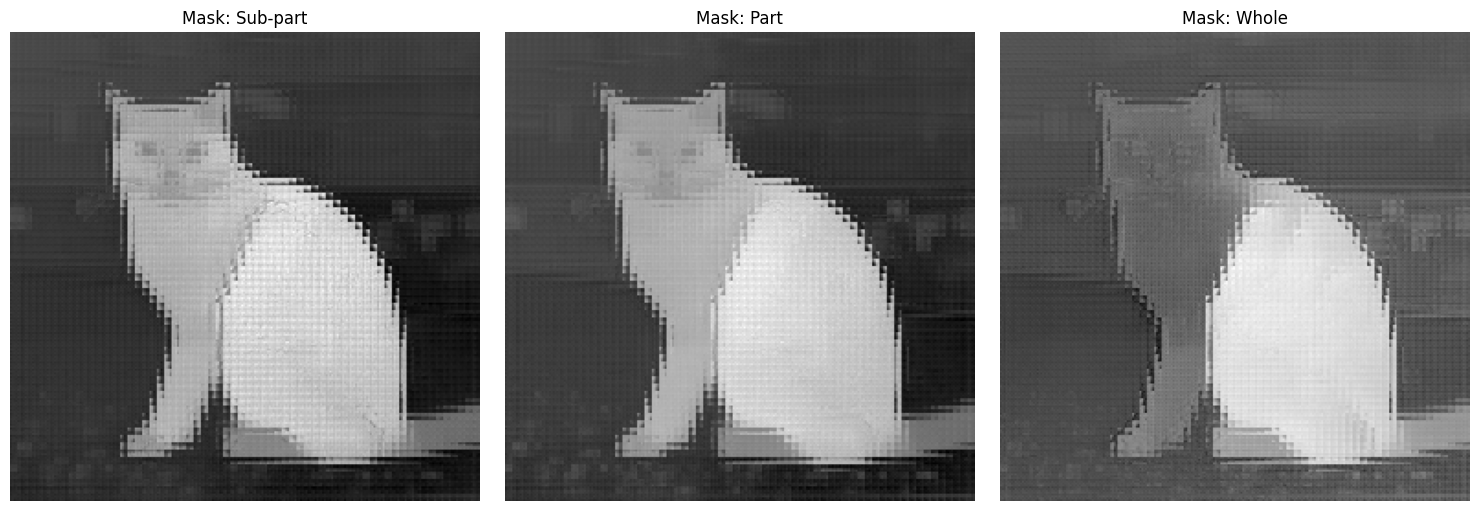

In [90]:
from matplotlib import pyplot as plt

def visualize_sam_masks(
    mask_data: jax.Array  # (3, 256, 256)
):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ["Mask: Sub-part", "Mask: Part", "Mask: Whole"]

    for i in range(3):
        axes[i].imshow(mask_data[i], cmap='gray')
        axes[i].set_title(titles[i])
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

visualize_sam_masks(jax_masks[0][0])


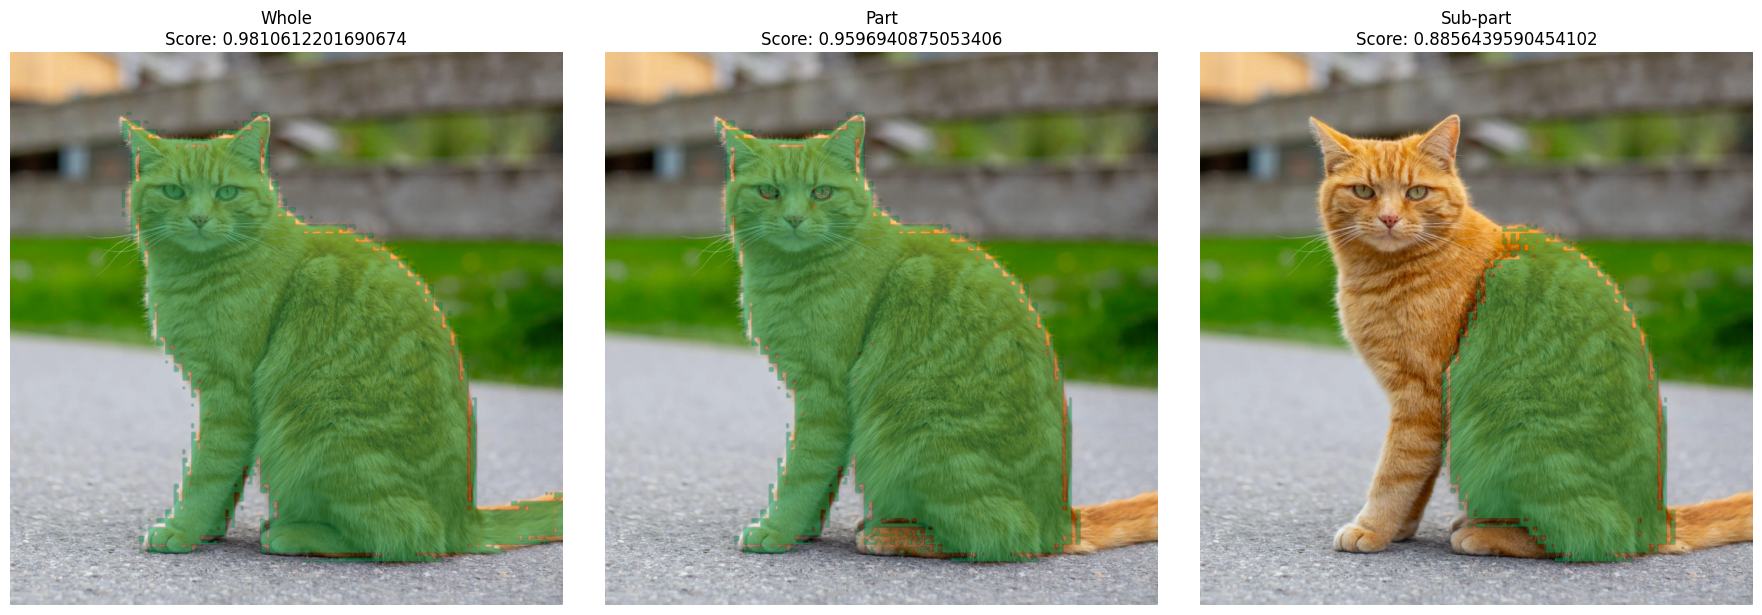

In [91]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_hf_sam(
    image_tensor: jax.Array,   # (1, 1024, 1024, 3)
    mask_tensor: jax.Array,    # (3, 256, 256)
    score_tensor: jax.Array    # (3,)
):
    img = image_tensor[0]

    mean = jnp.array([0.485, 0.456, 0.406])
    std = jnp.array([0.229, 0.224, 0.225])
    img = (img * std) + mean
    img = np.clip(img * 255, 0, 255).astype(np.uint8)

    masks = mask_tensor
    scores = score_tensor

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    titles = ["Whole", "Part", "Sub-part"]

    for i in range(3):
        ax = axes[i]
        ax.imshow(img)

        mask = masks[i] > 0

        mask_overlay = np.zeros((*mask.shape, 4))
        mask_overlay[mask] = [0, 0.6, 0.3, 0.5]

        ax.imshow(mask_overlay, extent=(0, 1024, 1024, 0), interpolation='bilinear')

        ax.set_title(f"{titles[i]}\nScore: {scores[i]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

visualize_hf_sam(image, jax_masks[0][0], iou_pred[0][0])
